In [80]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [81]:
import numpy as np
import json

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import LogLocator
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter

from pathlib import Path

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config, generate_config_seq
from utils.interpolator import OpenMCTallyGridSurrogate

from coupled.vapour_reactor import VapourReactor
from coupled.iso_reactor import Reactor

In [82]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)
    data["HeatPipe"]["material"]["h_cond"] = 550

MODEL_PATH = Path("./utils/rgi_surrogate.joblib")
interpolator_model = OpenMCTallyGridSurrogate()
interpolator_model = interpolator_model.load(MODEL_PATH)

In [83]:
Ns = [15, 30, 60]
cfg = generate_config(data, *Ns)

iso_reactor      = Reactor(cfg)
vap_reactor_800  = VapourReactor(cfg)
vap_reactor      = VapourReactor(cfg)
vap_reactor_full = VapourReactor(cfg)

vap_reactor.heatpipe.solid.k_temperature = 1100

vap_reactor_full.set_interpolator_model(interpolator_model)
vap_reactor_full.set_variable_k(True)

solver_iso = Solver([iso_reactor])
solver_vap = Solver([vap_reactor_800, vap_reactor, vap_reactor_full], iterate = True)
solver_iso.fsolve()
solver_vap.fsolve()

Mesh warning: N_Z changed from 60 to 69
Mesh warning: Fuel pin N_Z changed from 27 to 45
Mesh warning: Neutronics N_Z changed from 27 to 45
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolve message: The solution converged.
Running iteration 1 ...
fsolve message: The solution converged.
Running iteration 2 ...
fsolve message: The solution converged.
Running iteration 3 ...
fsolve message: The solution converged.


In [84]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "cm",
    "font.size": 30,
    "text.latex.preamble": r"""
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{siunitx}
        \usepackage{bm}
    """
})

colors = {
    "blue": "#0077BB",
    "cyan": "#33BBEE",
    "teal": "#009988",
    "orange": "#EE7733",
    "red": "#CC3311",
    "magenta": "#EE3377",
    "grey": "#BBBBBB"
}

cmap_orange = LinearSegmentedColormap.from_list(
    "blue_to_white",
    [colors["orange"], "white"]
)


In [85]:
(T_hp_iso, T_FP_iso, (phi_n_g_iso, k_iso)) = solver_iso.solutions[0]
((T_solid_vap, u_v, T_v), T_FP_vap, (phi_n_g_vap, k_vap)) = solver_vap.solutions[1]
((T_solid_vap_full, u_v_full, T_v_full), T_FP_vap_full, (phi_n_g_vap_full, k_vap_full)) = solver_vap.solutions[2]

z_hp = iso_reactor.heat_pipe_thermal_model.Z
z_fp = np.linspace(0, cfg.FP.geometry.l, cfg.FP.mesh.N_Z)

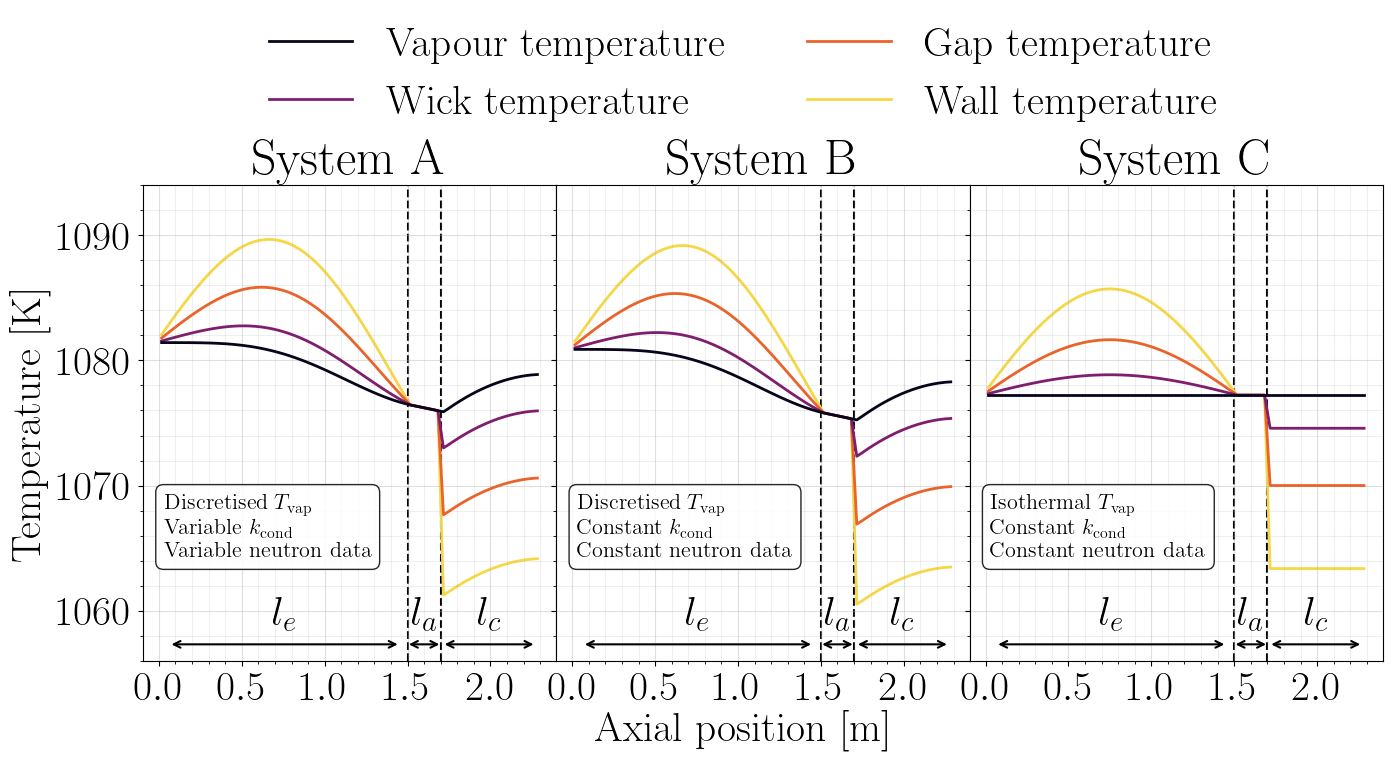

In [92]:
def add_axial_region_arrows(
    ax,
    z_bounds,
    labels=("A", "B", "C"),
    y_arrow_frac=0.035,
    y_text_frac=0.06,
    shrink=0.04,
    arrow_lw=1.5,
    fontsize=30,
):
    """
    Add double-headed arrows and labels for axial heat-pipe regions.

    z_bounds should be (z_min, z_evap, z_adiabatic, z_max).
    y positions are given as fractions of the axis height.
    """
    y_arrow = ymin + y_arrow_frac * (ymax - ymin)
    y_text  = ymin + y_text_frac  * (ymax - ymin)

    for z0, z1, label in zip(z_bounds[:-1], z_bounds[1:], labels):
        dz = z1 - z0

        x0 = z0 + shrink * dz
        x1 = z1 - shrink * dz
        xc = 0.5 * (z0 + z1)

        ax.annotate(
            "",
            xy=(x1, y_arrow),
            xytext=(x0, y_arrow),
            arrowprops=dict(
                arrowstyle="<->",
                color="black",
                lw=arrow_lw,
                shrinkA=0,
                shrinkB=0,
                mutation_scale = 12
            ),
            zorder=10,
        )

        ax.text(
            xc,
            y_text,
            label,
            ha="center",
            va="bottom",
            fontsize=fontsize,
            color="black",
            zorder=10,
        )


def add_model_textbox(ax, text, x=0.05, y=0.95, fontsize=16):
    ax.text(
        x,
        y,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=fontsize,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="black",
            alpha=0.85,
        ),
        zorder=20,
    )

fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(16, 7),
    sharey=True,
    gridspec_kw={"wspace": 0.0}
)

wick_slice = slice(0, cfg.HP.mesh.N_wick)
gap_slice = slice(cfg.HP.mesh.N_wick, cfg.HP.mesh.N_wick + cfg.HP.mesh.N_gap)
wall_slice = slice(cfg.HP.mesh.N_R - cfg.HP.mesh.N_wall, cfg.HP.mesh.N_R)

T_wick_avg = np.mean(T_solid_vap_full[:, wick_slice], axis=1)
T_gap_avg  = np.mean(T_solid_vap_full[:, gap_slice] , axis=1)
T_wall_avg = np.mean(T_solid_vap_full[:, wall_slice], axis=1)

T_wick_avg_vap = np.mean(T_solid_vap[:, wick_slice], axis=1)
T_gap_avg_vap  = np.mean(T_solid_vap[:, gap_slice] , axis=1)
T_wall_avg_vap = np.mean(T_solid_vap[:, wall_slice], axis=1)

T_wick_avg_iso = np.mean(T_hp_iso[0][:, wick_slice], axis=1)
T_gap_avg_iso  = np.mean(T_hp_iso[0][:, gap_slice] , axis=1)
T_wall_avg_iso = np.mean(T_hp_iso[0][:, wall_slice], axis=1)

# Pick colours from a colormap for the different plotted quantities
cmap = plt.get_cmap("inferno")

quantity_colors = {
    "vapour": cmap(0.05),
    "wick":   cmap(0.35),
    "gap":    cmap(0.65),
    "wall":   cmap(0.90),
}

# Discretised vapour reactor, variable k, variable neutron data
ax1.plot(z_hp, T_v_full,   color=quantity_colors["vapour"], lw=2, linestyle="-", zorder=4)
ax1.plot(z_hp, T_wick_avg, color=quantity_colors["wick"],   lw=2, linestyle="-", zorder=3)
ax1.plot(z_hp, T_gap_avg,  color=quantity_colors["gap"],    lw=2, linestyle="-", zorder=2)
ax1.plot(z_hp, T_wall_avg, color=quantity_colors["wall"],   lw=2, linestyle="-", zorder=1)

# Discretised vapour reactor, constant k, constant neutron data
ax2.plot(z_hp, T_v,            color=quantity_colors["vapour"], lw=2, linestyle="-", zorder=4)
ax2.plot(z_hp, T_wick_avg_vap, color=quantity_colors["wick"],   lw=2, linestyle="-", zorder=3)
ax2.plot(z_hp, T_gap_avg_vap,  color=quantity_colors["gap"],    lw=2, linestyle="-", zorder=2)
ax2.plot(z_hp, T_wall_avg_vap, color=quantity_colors["wall"],   lw=2, linestyle="-", zorder=1)

# Isothermal vapour reactor
ax3.plot(z_hp, np.full(z_hp.shape, T_hp_iso[-1]), color=quantity_colors["vapour"], lw=2, linestyle="-", zorder=4)
ax3.plot(z_hp, T_wick_avg_iso,                    color=quantity_colors["wick"],   lw=2, linestyle="-", zorder=3)
ax3.plot(z_hp, T_gap_avg_iso,                     color=quantity_colors["gap"],    lw=2, linestyle="-", zorder=2)
ax3.plot(z_hp, T_wall_avg_iso,                    color=quantity_colors["wall"],   lw=2, linestyle="-", zorder=1)

ymax, ymin = 1094, 1056
z_evap = cfg.HP.geometry.l_evap
z_adiabatic = cfg.HP.geometry.l_evap + cfg.HP.geometry.l_adiabatic

ax1.set_ylim((ymin, ymax))
ax2.set_ylim((ymin, ymax))
ax3.set_ylim((ymin, ymax))

ax1.set_title("System A")
ax2.set_title("System B")
ax3.set_title("System C")

add_model_textbox(
    ax1,
    "Discretised $T_\\mathrm{vap}$\nVariable $k_\\mathrm{cond}$\nVariable neutron data",
    y=0.35
)

add_model_textbox(
    ax2,
    "Discretised $T_\\mathrm{vap}$\nConstant $k_\\mathrm{cond}$\nConstant neutron data",
    y=0.35
)

add_model_textbox(
    ax3,
    "Isothermal $T_\\mathrm{vap}$\nConstant $k_\\mathrm{cond}$\nConstant neutron data",
    y=0.35
)

# dash_style = (5, (10, 3))

for ax in (ax1, ax2, ax3):
    ax.vlines(
        (z_evap, z_adiabatic),
        ymin,
        ymax,
        colors="black",
        linestyles="--",
        zorder=0,
    )

z_bounds = (
    np.min(z_hp),
    z_evap,
    z_adiabatic,
    np.max(z_hp),
)

for ax in (ax1, ax2, ax3):
    add_axial_region_arrows(
        ax,
        z_bounds,
        labels=(r"$l_e$", r"$l_a$", r"$l_c$"),
    )

ax1.minorticks_on()
ax2.minorticks_on()
ax3.minorticks_on()

ax1.set_ylabel(r"Temperature [$\si{\kelvin}$]", fontsize=30)
# ax1.set_xlabel("Axial position [m]")
# ax2.set_xlabel("Axial position [m]")
# ax3.set_xlabel("Axial position [m]")
fig.supxlabel(r"Axial position [$\si{\meter}$]", fontsize=30)

ax1.grid(which="major", alpha=0.4)
ax1.grid(which="minor", alpha=0.2)
ax2.grid(which="major", alpha=0.4)
ax2.grid(which="minor", alpha=0.2)
ax3.grid(which="major", alpha=0.4)
ax3.grid(which="minor", alpha=0.2)

# ax1.set_xlim((0, 2.3))
# ax2.set_xlim((0, 2.3))
# ax3.set_xlim((0, 2.3))

ax1.xaxis.set_major_locator(MultipleLocator(0.5))
ax2.xaxis.set_major_locator(MultipleLocator(0.5))
ax3.xaxis.set_major_locator(MultipleLocator(0.5))

quantity_handles = [
    ax1.plot([], [], color=quantity_colors["vapour"], lw=2, linestyle="-",
             label="Vapour temperature")[0],
    ax1.plot([], [], color=quantity_colors["wick"], lw=2, linestyle="-",
             label="Wick temperature")[0],
    ax1.plot([], [], color=quantity_colors["gap"], lw=2, linestyle="-",
             label="Gap temperature")[0],
    ax1.plot([], [], color=quantity_colors["wall"], lw=2, linestyle="-",
             label="Wall temperature")[0],
]

fig.legend(
    handles=quantity_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=2,
    frameon=False,
)

fig.subplots_adjust(
    top=0.82,
    bottom=0.14
)

# Hide labels on the right plot, but keep ticks for the grid
ax2.tick_params(axis="y", labelleft=False)
ax3.tick_params(axis="y", labelleft=False)

plt.savefig("./outputs/report_figures/reactor_results/axial_heatpipe.pdf", bbox_inches="tight")
plt.show()

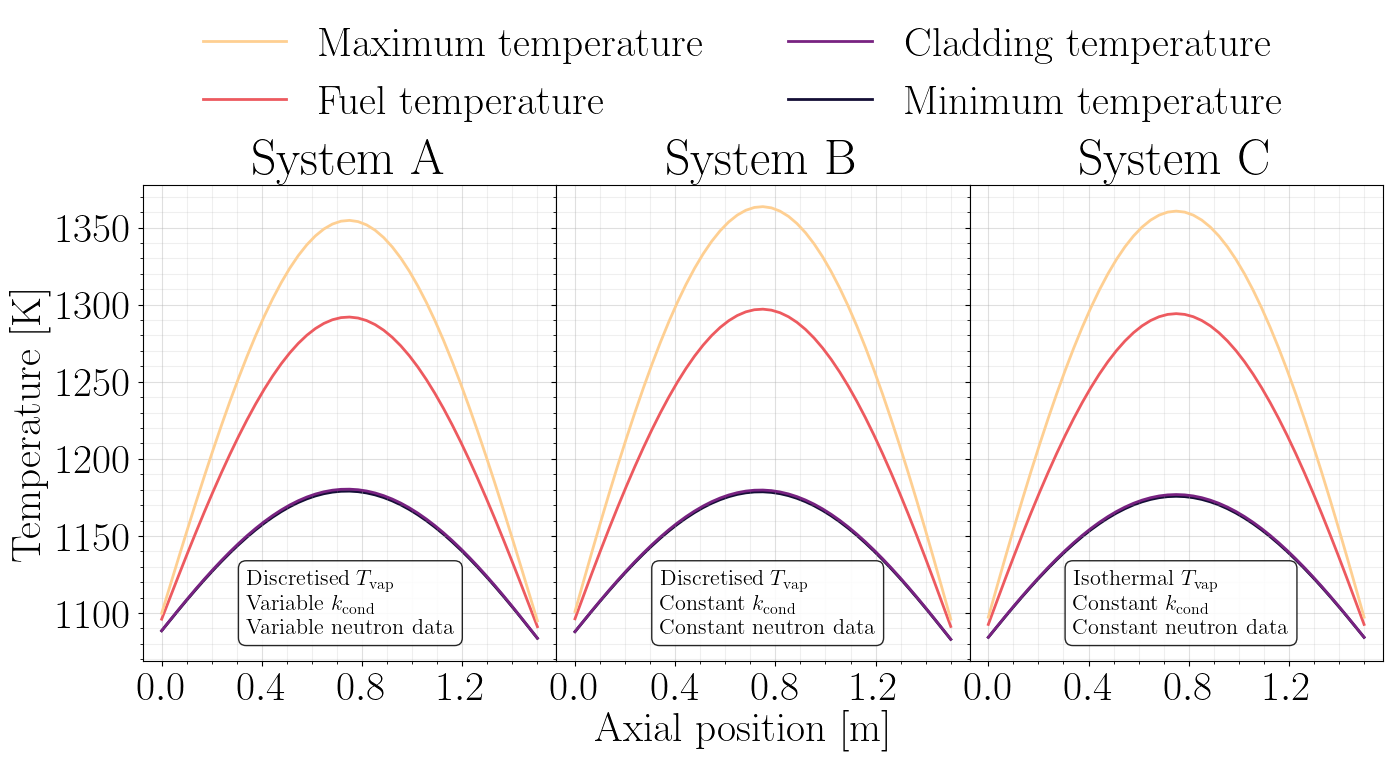

In [94]:
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(16, 7),
    sharey=True,
    gridspec_kw={"wspace": 0.0}
)

fuel_slice = slice(0, cfg.FP.mesh.N_fuel)
gap_slice  = slice(cfg.FP.mesh.N_fuel, cfg.FP.mesh.N_fuel + cfg.FP.mesh.N_gap)
clad_slice = slice(cfg.FP.mesh.N_fuel + cfg.FP.mesh.N_gap, cfg.FP.mesh.N_R)

# Average temperatures
T_fuel_avg_full = np.mean(T_FP_vap_full[:, fuel_slice], axis=1)
T_clad_avg_full = np.mean(T_FP_vap_full[:, clad_slice], axis=1)

T_fuel_avg = np.mean(T_FP_vap[:, fuel_slice], axis=1)
T_clad_avg = np.mean(T_FP_vap[:, clad_slice], axis=1)

T_fuel_avg_iso = np.mean(T_FP_iso[:, fuel_slice], axis=1)
T_clad_avg_iso = np.mean(T_FP_iso[:, clad_slice], axis=1)

# Radial slice indices corresponding to the global max/min temperatures
i_max_full = np.unravel_index(np.argmax(T_FP_vap_full), T_FP_vap_full.shape)[1]
i_min_full = np.unravel_index(np.argmin(T_FP_vap_full), T_FP_vap_full.shape)[1]

i_max = np.unravel_index(np.argmax(T_FP_vap), T_FP_vap.shape)[1]
i_min = np.unravel_index(np.argmin(T_FP_vap), T_FP_vap.shape)[1]

i_max_iso = np.unravel_index(np.argmax(T_FP_iso), T_FP_iso.shape)[1]
i_min_iso = np.unravel_index(np.argmin(T_FP_iso), T_FP_iso.shape)[1]

# Axial profiles of those radial slices
T_max_slice_full = T_FP_vap_full[:, i_max_full]
T_min_slice_full = T_FP_vap_full[:, i_min_full]

T_max_slice = T_FP_vap[:, i_max]
T_min_slice = T_FP_vap[:, i_min]

T_max_slice_iso = T_FP_iso[:, i_max_iso]
T_min_slice_iso = T_FP_iso[:, i_min_iso]

cmap = plt.get_cmap("magma")
quantity_colors = {
    "min":  cmap(0.10),
    "clad": cmap(0.35),
    "fuel": cmap(0.65),
    "max":  cmap(0.90),
}

# Variable-k vapour reactor
ax1.plot(z_fp, T_max_slice_full, color=quantity_colors["max"],  lw=2, linestyle="-", zorder=4)
ax1.plot(z_fp, T_fuel_avg_full,  color=quantity_colors["fuel"], lw=2, linestyle="-", zorder=3)
ax1.plot(z_fp, T_clad_avg_full,  color=quantity_colors["clad"], lw=2, linestyle="-", zorder=2)
ax1.plot(z_fp, T_min_slice_full, color=quantity_colors["min"],  lw=2, linestyle="-", zorder=1)

# Constant-k vapour reactor
ax2.plot(z_fp, T_max_slice, color=quantity_colors["max"],  lw=2, linestyle="-", zorder=4)
ax2.plot(z_fp, T_fuel_avg,  color=quantity_colors["fuel"], lw=2, linestyle="-", zorder=3)
ax2.plot(z_fp, T_clad_avg,  color=quantity_colors["clad"], lw=2, linestyle="-", zorder=2)
ax2.plot(z_fp, T_min_slice, color=quantity_colors["min"],  lw=2, linestyle="-", zorder=1)

# Isothermal reactor
ax3.plot(z_fp, T_max_slice_iso, color=quantity_colors["max"],  lw=2, linestyle="-", zorder=4)
ax3.plot(z_fp, T_fuel_avg_iso,  color=quantity_colors["fuel"], lw=2, linestyle="-", zorder=3)
ax3.plot(z_fp, T_clad_avg_iso,  color=quantity_colors["clad"], lw=2, linestyle="-", zorder=2)
ax3.plot(z_fp, T_min_slice_iso, color=quantity_colors["min"],  lw=2, linestyle="-", zorder=1)

for ax in (ax1, ax2, ax3):
    ax.minorticks_on()
    ax.grid(which="major", alpha=0.4)
    ax.grid(which="minor", alpha=0.2)
    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_major_locator(MultipleLocator(50))

ax1.set_ylabel(r"Temperature [\si{\kelvin}]", fontsize=30)
fig.supxlabel(r"Axial position [$\si{\meter}$]", fontsize=30)

ax1.set_title("System A")
ax2.set_title("System B")
ax3.set_title("System C")

ax2.tick_params(axis="y", labelleft=False)
ax3.tick_params(axis="y", labelleft=False)

ax1.xaxis.set_major_locator(MultipleLocator(0.4))
ax2.xaxis.set_major_locator(MultipleLocator(0.4))
ax3.xaxis.set_major_locator(MultipleLocator(0.4))

add_model_textbox(
    ax1,
    "Discretised $T_\\mathrm{vap}$\nVariable $k_\\mathrm{cond}$\nVariable neutron data",
    y=0.19,
    x=0.25
)

add_model_textbox(
    ax2,
    "Discretised $T_\\mathrm{vap}$\nConstant $k_\\mathrm{cond}$\nConstant neutron data",
    y=0.19,
    x=0.25
)

add_model_textbox(
    ax3,
    "Isothermal $T_\\mathrm{vap}$\nConstant $k_\\mathrm{cond}$\nConstant neutron data",
    y=0.19,
    x=0.25
)

color_handles = [
    Line2D([0], [0], color=quantity_colors["max"],  lw=2, linestyle="-", label="Maximum temperature"),
    Line2D([0], [0], color=quantity_colors["fuel"], lw=2, linestyle="-", label="Fuel temperature"),
    Line2D([0], [0], color=quantity_colors["clad"], lw=2, linestyle="-", label="Cladding temperature"),
    Line2D([0], [0], color=quantity_colors["min"],  lw=2, linestyle="-", label="Minimum temperature"),
]

fig.legend(
    handles=color_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=2,
    frameon=False,
    fontsize=30
)
fig.subplots_adjust(
    top=0.82,
    bottom=0.14
)

plt.savefig(r"./outputs/report_figures/reactor_results/axial_fuelpin.pdf", bbox_inches="tight")
plt.show()

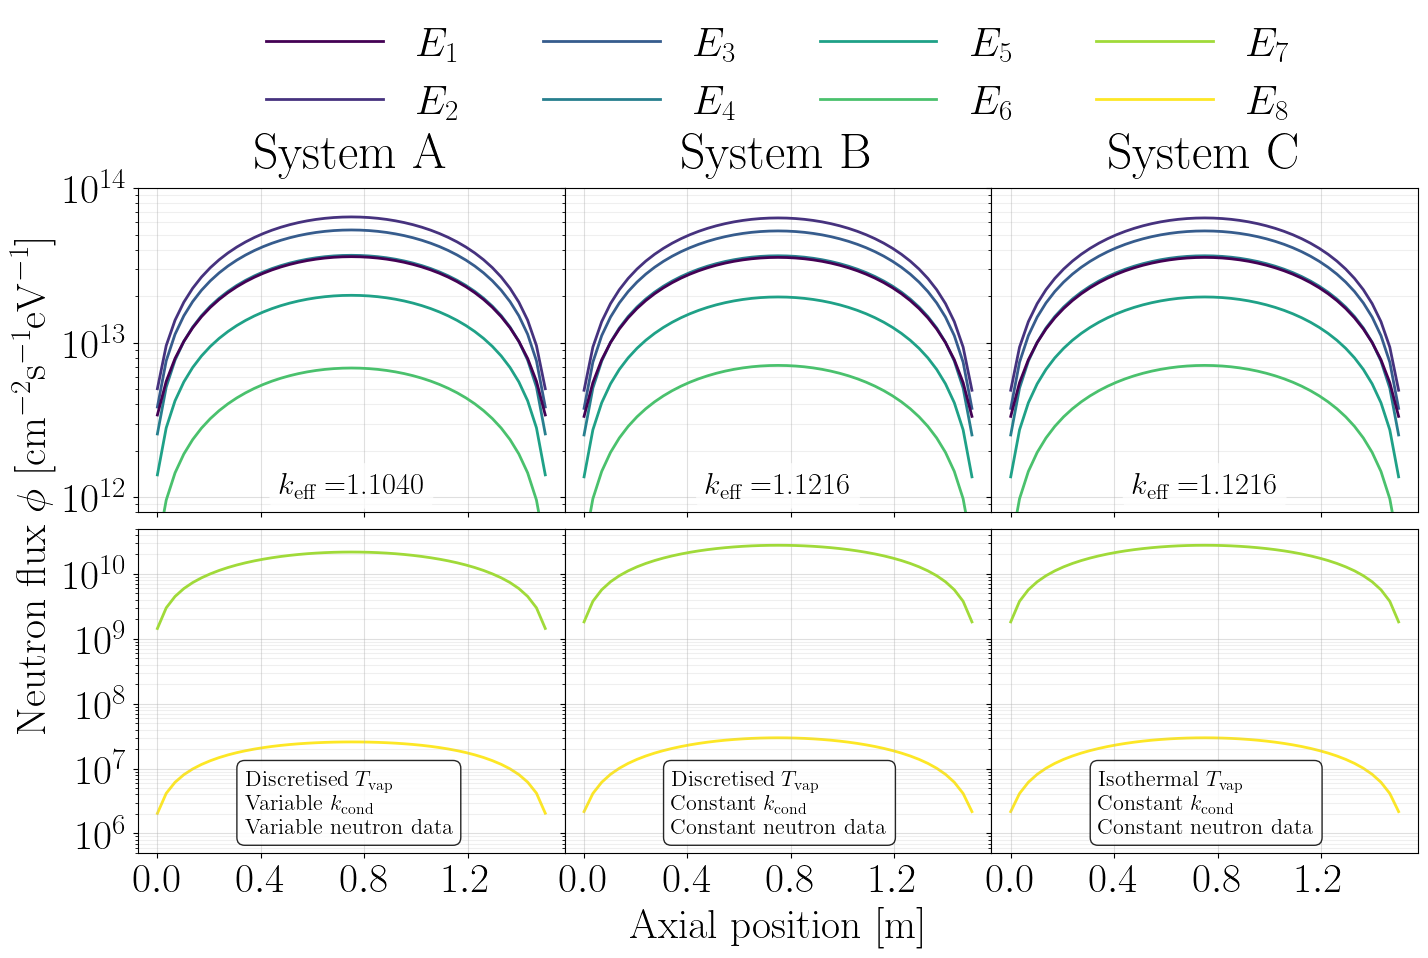

In [95]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, LogLocator, LogFormatterMathtext, NullFormatter
import numpy as np
import matplotlib.pyplot as plt

def add_free_text(ax, text, x=0.5, y=0.05, fontsize=22):
    ax.text(
        x, y,
        text,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=fontsize,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
        ),
        zorder=20,
    )

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 9.5),
    sharex=True,
    sharey="row",
    gridspec_kw={
        "wspace": 0.0,
        "hspace": 0.05,
    }
)

ax1, ax2, ax3 = axes[0]
ax4, ax5, ax6 = axes[1]

N_G = phi_n_g_vap_full.shape[1]

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, N_G))

# Top row: all groups except the two lowest-flux ones
top_indices = range(0, max(N_G - 2, 0))

# Bottom row: the two lowest-flux groups (highest E indices)
bottom_indices = range(max(N_G - 2, 0), N_G)

# Top row
for i in top_indices:
    ax1.plot(z_fp, 1e-4*phi_n_g_vap_full[:, i], color=colors[i], lw=2, linestyle="-", zorder=8 - i)
    ax2.plot(z_fp, 1e-4*phi_n_g_vap[:, i],      color=colors[i], lw=2, linestyle="-", zorder=8 - i)
    ax3.plot(z_fp, 1e-4*phi_n_g_iso[:, i],      color=colors[i], lw=2, linestyle="-", zorder=8 - i)

# Bottom row
for i in bottom_indices:
    ax4.plot(z_fp, 1e-4*phi_n_g_vap_full[:, i], color=colors[i], lw=2, linestyle="-", zorder=8 - i)
    ax5.plot(z_fp, 1e-4*phi_n_g_vap[:, i],      color=colors[i], lw=2, linestyle="-", zorder=8 - i)
    ax6.plot(z_fp, 1e-4*phi_n_g_iso[:, i],      color=colors[i], lw=2, linestyle="-", zorder=8 - i)

# Common formatting
for ax in axes.flat:
    ax.set_yscale("log")

    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))

    ax.yaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100)
    )
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.xaxis.set_major_locator(MultipleLocator(0.4))

    ax.grid(which="major", alpha=0.4)
    ax.grid(which="minor", alpha=0.2)

# Y-limits
# Top row: E_0 ... E_5 (for 8 groups)
for ax in (ax1, ax2, ax3):
    ax.set_ylim((8e15*1e-4, 1e18*1e-4))

# Bottom row: E_6, E_7 (for 8 groups)
for ax in (ax4, ax5, ax6):
    ax.set_ylim((5e9*1e-4, 5e14*1e-4))

# Titles
ax1.set_title("System A", pad=14)
ax2.set_title("System B", pad=14)
ax3.set_title("System C", pad=14)

# Free text in bottom of upper subplots
add_free_text(ax1, r"$k_\text{eff} = $" + f"{k_vap_full:.4f}", x=0.5, y=0.04)
add_free_text(ax2, r"$k_\text{eff} = $" + f"{k_vap:.4f}"     , x=0.5, y=0.04)
add_free_text(ax3, r"$k_\text{eff} = $" + f"{k_iso:.4f}"     , x=0.5, y=0.04)

# Axis labels
units = r"\si{\centi\meter^{-2}\second^{-1}\electronvolt^{-1}}"

fig.supylabel(rf"Neutron flux $\phi$ [{units}]", fontsize=30)

fig.supxlabel(r"Axial position [$\si{\meter}$]", fontsize=30)

# Hide y tick labels on non-left plots
for ax in (ax2, ax3, ax5, ax6):
    ax.tick_params(axis="y", labelleft=False)

# Hide x tick labels on top row
for ax in (ax1, ax2, ax3):
    ax.tick_params(axis="x", labelbottom=False)

# Description boxes in bottom row
add_model_textbox(
    ax4,
    "Discretised $T_\\mathrm{vap}$\nVariable $k_\\mathrm{cond}$\nVariable neutron data",
    y=0.255,
    x=0.25
)

add_model_textbox(
    ax5,
    "Discretised $T_\\mathrm{vap}$\nConstant $k_\\mathrm{cond}$\nConstant neutron data",
    y=0.255,
    x=0.25
)

add_model_textbox(
    ax6,
    "Isothermal $T_\\mathrm{vap}$\nConstant $k_\\mathrm{cond}$\nConstant neutron data",
    y=0.255,
    x=0.25
)

# Legend: all plotted groups
color_handles = [
    Line2D([0], [0], color=colors[i], lw=2, linestyle="-", label=rf"$E_{i+1}$")
    for i in range(N_G)
]

fig.legend(
    handles=color_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=False,
    handlelength=2.8,
)

# Extra top room so legend does not overlap titles
fig.subplots_adjust(
    top=0.81,
    bottom=0.11,
    left=0.1,
)

plt.savefig(r"./outputs/report_figures/reactor_results/axial_neutron.pdf")
plt.show()